## High resolution grids AGN spectra

In [1]:
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import os
from astropy.constants import c
import astropy.units as u
from astropy.cosmology import Planck15 as cosmo
from unyt import kpc, rad, km, unyt_array, s
import os
import numpy as np
from astropy.table import Table
from astropy.io import fits
from astropy import units as u
import numpy as np
from unyt import rad
from astropy.constants import c
from astropy import units as u
from unyt import arcsec, rad, kpc, degree
from unyt import Mpc, Msun, Myr, cm, kelvin, yr
from copy import deepcopy
import astropy.units as u
from synthesizer.kernel_functions import Kernel
from synthesizer.particle.stars import Stars
from synthesizer.particle.gas import Gas
from synthesizer.particle.blackholes import BlackHoles

# Synthesizer
from synthesizer.grid import Grid
from synthesizer.emission_models import (
    EmissionModel,
    AttenuatedEmission,
    DustEmission,
    UnifiedAGN,
    BimodalPacmanEmission,
    IncidentEmission
)
from synthesizer.emission_models.attenuation import PowerLaw
from synthesizer.load_data.load_camels import load_CAMELS_IllustrisTNG
from synthesizer.emission_models.generators.dust import Blackbody, Greybody
from unyt import Msun, Myr, degree, km, kpc, s
from synthesizer import TEST_DATA_DIR

# load my own camels data_loader that includes the BH component from simulations
from data_loader import load_CAMELS_IllustrisTNG as TNG_load


### Set up low res emission model 

In [2]:
# synthesizer example grids with low resolution for testing
grid_lowres = Grid("bc03-2016-Miles_chabrier-0.1,100_cloudy-c23.01-sps.hdf5")
nlr_grid_lowres = Grid("test_grid_agn-nlr.hdf5")
blr_grid_lowres = Grid("test_grid_agn-blr.hdf5")


uni_model_low_res = UnifiedAGN(
    nlr_grid_lowres,
    blr_grid_lowres,
    covering_fraction_nlr=0.01,
    covering_fraction_blr=0.1,
    torus_emission_model=Greybody(1000 * kelvin),
    label="agn_intrinsic",)

pc_model_low_res = BimodalPacmanEmission(
        grid=grid_lowres,
        tau_v_ism=0.0,
        tau_v_birth=0.7,
        dust_curve_ism=PowerLaw(-1.3),
        dust_curve_birth=PowerLaw(-0.7),
        dust_emission_ism=Blackbody(100 * kelvin),
        dust_emission_birth=Blackbody(30 * kelvin),
        fesc=0.2,
        fesc_ly_alpha=0.9,
        label="stellar_total",
    )


gal_intrinsic_low_res = EmissionModel(
        label="total_intrinsic",
        combine=(uni_model_low_res, pc_model_low_res),  
        emitter="galaxy",
    )

att_uni_model_low_res = AttenuatedEmission(
        dust_curve=PowerLaw(-1.0),
        apply_to=uni_model_low_res, 
        tau_v=0.0,
        emitter="blackhole",
        label="agn_attenuated",
    )

gal_attenuated_low_res = EmissionModel(
        label="total_attenuated",
        combine=(att_uni_model_low_res, pc_model_low_res),  
        related_models=(gal_intrinsic_low_res,),
        emitter="galaxy",
    )

gal_dust_low_res = DustEmission(
        dust_emission_model=Greybody(30 * kelvin, 1.2),
        dust_lum_intrinsic=gal_intrinsic_low_res,
        dust_lum_attenuated=gal_attenuated_low_res,
        emitter="galaxy",
        label="dust_emission",
    )

gal_total_low_res = EmissionModel(
        label="total",
        combine=(gal_attenuated_low_res, gal_dust_low_res),
        related_models=(gal_intrinsic_low_res,),
        emitter="galaxy",
    )



### Set up high res emission model

In [3]:
# My high resolution grids 
grid_high_res = Grid("bc03-2016-Miles_chabrier-0.1,100_cloudy-c25.00-sps.hdf5")
nlr_grid_high_res = Grid("relagn_incident_fixed_rad_efficiency_0p1_reduced_cloudy-c25.00-nlr.hdf5")
blr_grid_high_res = Grid("relagn_incident_fixed_rad_efficiency_0p1_reduced_cloudy-c25.00-blr.hdf5")


uni_model_high_res = UnifiedAGN(
    nlr_grid_high_res,
    blr_grid_high_res,
    covering_fraction_nlr=0.01,
    covering_fraction_blr=0.1,
    torus_emission_model=Greybody(1000 * kelvin),
    label="agn_intrinsic",)

pc_model_high_res = BimodalPacmanEmission(
        grid=grid_high_res,
        tau_v_ism=0.0,
        tau_v_birth=0.7,
        dust_curve_ism=PowerLaw(-1.3),
        dust_curve_birth=PowerLaw(-0.7),
        dust_emission_ism=Blackbody(100 * kelvin),
        dust_emission_birth=Blackbody(30 * kelvin),
        fesc=0.2,
        fesc_ly_alpha=0.9,
        label="stellar_total",
    )


gal_intrinsic_high_res = EmissionModel(
        label="total_intrinsic",
        combine=(uni_model_high_res, pc_model_high_res),  
        emitter="galaxy",
    )

att_uni_model_high_res = AttenuatedEmission(
        dust_curve=PowerLaw(-1.0),
        apply_to=uni_model_high_res, 
        tau_v=0.0,
        emitter="blackhole",
        label="agn_attenuated",
    )

gal_attenuated_high_res = EmissionModel(
        label="total_attenuated",
        combine=(att_uni_model_high_res, pc_model_high_res),  
        related_models=(gal_intrinsic_high_res,),
        emitter="galaxy",
    )

gal_dust_high_res = DustEmission(
        dust_emission_model=Greybody(30 * kelvin, 1.2),
        dust_lum_intrinsic=gal_intrinsic_high_res,
        dust_lum_attenuated=gal_attenuated_high_res,
        emitter="galaxy",
        label="dust_emission",
    )

gal_total_high_res = EmissionModel(
        label="total",
        combine=(gal_attenuated_high_res, gal_dust_high_res),
        related_models=(gal_intrinsic_high_res,),
        emitter="galaxy",
    )


### Load Galaxies

In [4]:
## Testing on TNG50_3 data
snapshot=84
galaxies = TNG_load(
    _dir="/data/Euclid_Q1/TNG50/_3",
    snap_name=f"snapshot_0{snapshot}.hdf5",
    group_name=f"groups_0{snapshot}.hdf5",
)
print("Number of potential galaxies:", len(galaxies))


/home/teresa/Data/synthesizer/venv-Leddington/lib/python3.10/site-packages/unyt/array.py:1972: RuntimeWarning: invalid value encountered in divide
  out_arr = func(
/home/teresa/Data/synthesizer/venv-Leddington/lib/python3.10/site-packages/unyt/array.py:1972: RuntimeWarning: overflow encountered in multiply
  out_arr = func(
/home/teresa/Data/synthesizer/venv-Leddington/lib/python3.10/site-packages/unyt/array.py:1972: RuntimeWarning: overflow encountered in multiply
  out_arr = func(
/home/teresa/Data/synthesizer/venv-Leddington/lib/python3.10/site-packages/unyt/array.py:1972: RuntimeWarning: overflow encountered in multiply
  out_arr = func(
/home/teresa/Data/synthesizer/venv-Leddington/lib/python3.10/site-packages/unyt/array.py:1972: RuntimeWarning: overflow encountered in multiply
  out_arr = func(
/home/teresa/Data/synthesizer/venv-Leddington/lib/python3.10/site-packages/unyt/array.py:1972: RuntimeWarning: overflow encountered in multiply
  out_arr = func(
/home/teresa/Data/synthes

Number of potential galaxies: 139445


### Select AGN

They must have at least 100 star particles, a BH particle, and an Eddington ratio > 0.001 

In [5]:
agn = [g for g in galaxies if getattr(g, "stars", None) is not None
           and g.stars.nparticles > 100
           and getattr(g, "black_holes", None) is not None
           and np.any(g.black_holes.eddington_ratio > 0.001)
           ]

print("Number of AGN candidates:", len(agn))

Number of AGN candidates: 928


### Get low res spectra (plot DESI wavelengths)

In [6]:
candidate = agn[0]

z_obs = candidate.redshift

spec = candidate.get_spectra(emission_model=gal_total_low_res)
lam_rest = spec.lam.to("Angstrom").value
lnu_rest = spec.lnu.to("erg/s/Hz").value


d_lum = cosmo.luminosity_distance(z_obs).to("cm").value

lam_obs = lam_rest * (1.0 + z_obs)

fnu_obs = lnu_rest * (1.0 + z_obs) / (4.0 * np.pi * d_lum**2)

c_AA_per_s = c.value * 1e10
flam_obs = fnu_obs * c_AA_per_s / lam_obs**2

wave_desi = np.arange(3533.0, 9913.0 + 0.2, 0.2)

interp = interp1d(
    lam_obs,
    flam_obs,
    bounds_error=False,
    fill_value=0.0
)

flam_desi = interp(wave_desi)

/home/teresa/Data/synthesizer/venv-Leddington/lib/python3.10/site-packages/unyt/array.py:1832: RuntimeWarning: overflow encountered in exp
  out_arr = func(np.asarray(inp), out=out_func, **kwargs)
/home/teresa/Data/synthesizer/venv-Leddington/lib/python3.10/site-packages/unyt/array.py:1972: RuntimeWarning: overflow encountered in multiply
  out_arr = func(


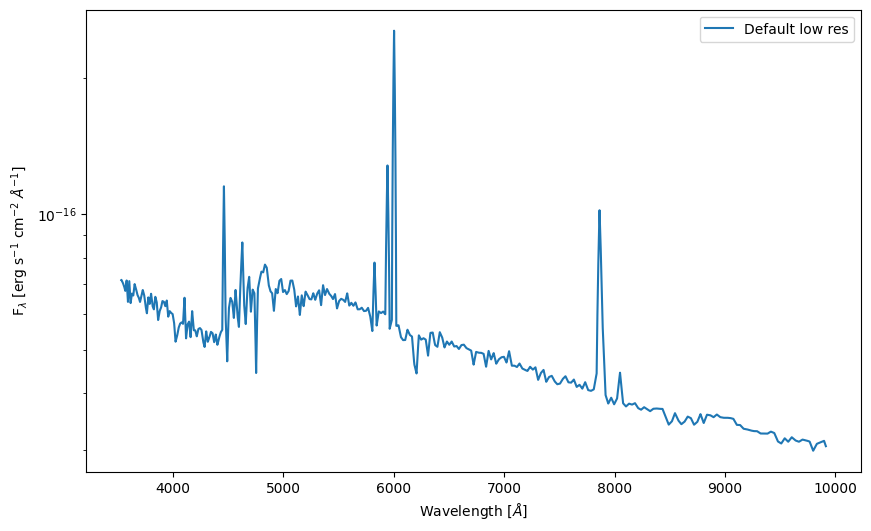

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(wave_desi, flam_desi, label='Default low res')
plt.yscale('log')
plt.xlim()
plt.legend()
plt.xlabel(r'Wavelength [$\AA$]')
plt.ylabel(r'F$_\lambda$ [erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$]')
plt.show()

### Get high res spectra (plot DESI wavelengths)

In [8]:
candidate = agn[0]

z_obs = candidate.redshift

spec = candidate.get_spectra(emission_model=gal_total_high_res)
lam_rest = spec.lam.to("Angstrom").value
lnu_rest = spec.lnu.to("erg/s/Hz").value


d_lum = cosmo.luminosity_distance(z_obs).to("cm").value

lam_obs = lam_rest * (1.0 + z_obs)

fnu_obs = lnu_rest * (1.0 + z_obs) / (4.0 * np.pi * d_lum**2)

c_AA_per_s = c.value * 1e10
flam_obs = fnu_obs * c_AA_per_s / lam_obs**2

wave_desi = np.arange(3533.0, 9913.0 + 0.2, 0.2)

interp = interp1d(
    lam_obs,
    flam_obs,
    bounds_error=False,
    fill_value=0.0
)

flam_desi = interp(wave_desi)

MissingAttribute: None can't be found on the model (disc_incident_masked), emission (None), or emitter (BlackHoles).  [EmissionModel.label: disc_incident_masked] 